## Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score, GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import xgboost
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score,roc_curve
from imblearn.over_sampling import SMOTE
from matplotlib_venn import venn3,venn3_circles,venn3_unweighted

import warnings
warnings.filterwarnings("ignore")

## Loading Dataset

In [2]:
# Load dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Data inspection

In [4]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [5]:
# this return the number of rows and columns  in the dataset
df.shape

(5110, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [7]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [8]:
# shows people who have heart disease but have not had a stroke
h_s = df[(df["heart_disease"]== 1) & (df["stroke"] == 0)]
h_s

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
256,41413,Female,75.0,0,1,Yes,Self-employed,Rural,243.53,27.0,never smoked,0
260,64908,Male,79.0,0,1,Yes,Private,Urban,57.08,22.0,formerly smoked,0
268,17986,Female,79.0,0,1,Yes,Self-employed,Urban,67.84,25.2,smokes,0
315,41940,Male,57.0,0,1,Yes,Private,Rural,62.20,31.0,formerly smoked,0
337,56357,Female,82.0,0,1,No,Private,Urban,215.60,24.9,never smoked,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4855,42563,Female,57.0,1,1,Yes,Private,Rural,231.72,45.7,formerly smoked,0
4869,72715,Female,50.0,0,1,Yes,Private,Urban,193.80,26.4,never smoked,0
4921,4062,Male,72.0,0,1,Yes,Private,Rural,238.27,NaN,smokes,0
4986,53697,Male,58.0,0,1,Yes,Private,Rural,225.35,26.5,smokes,0


## Exploratory Data Analysis


### 1. Data Cleaning

In [9]:
# checking for missing or null values
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [10]:
df.drop(columns=['id'], inplace=True)

In [11]:
#checking for duplicated
df.duplicated().sum()

0

In [12]:
# filling missing rows with the median
bmi_median = df['bmi'].median()
df['bmi'] = df['bmi'].fillna(bmi_median)

print(f"Missing values in 'bmi' after filling: {df['bmi'].isnull().sum()}")
print(f'Median value used:{bmi_median}')

Missing values in 'bmi' after filling: 0
Median value used:28.1


### 2. Data Visualization

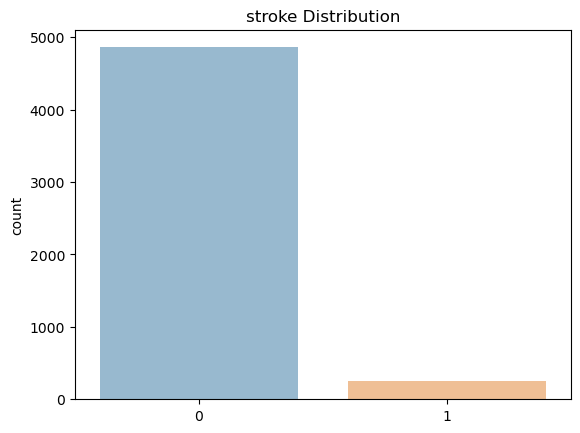

In [13]:
sns.countplot(data=df, x=df['stroke'], alpha=0.5)
plt.xlabel('')
plt.title('stroke Distribution')
plt.show()

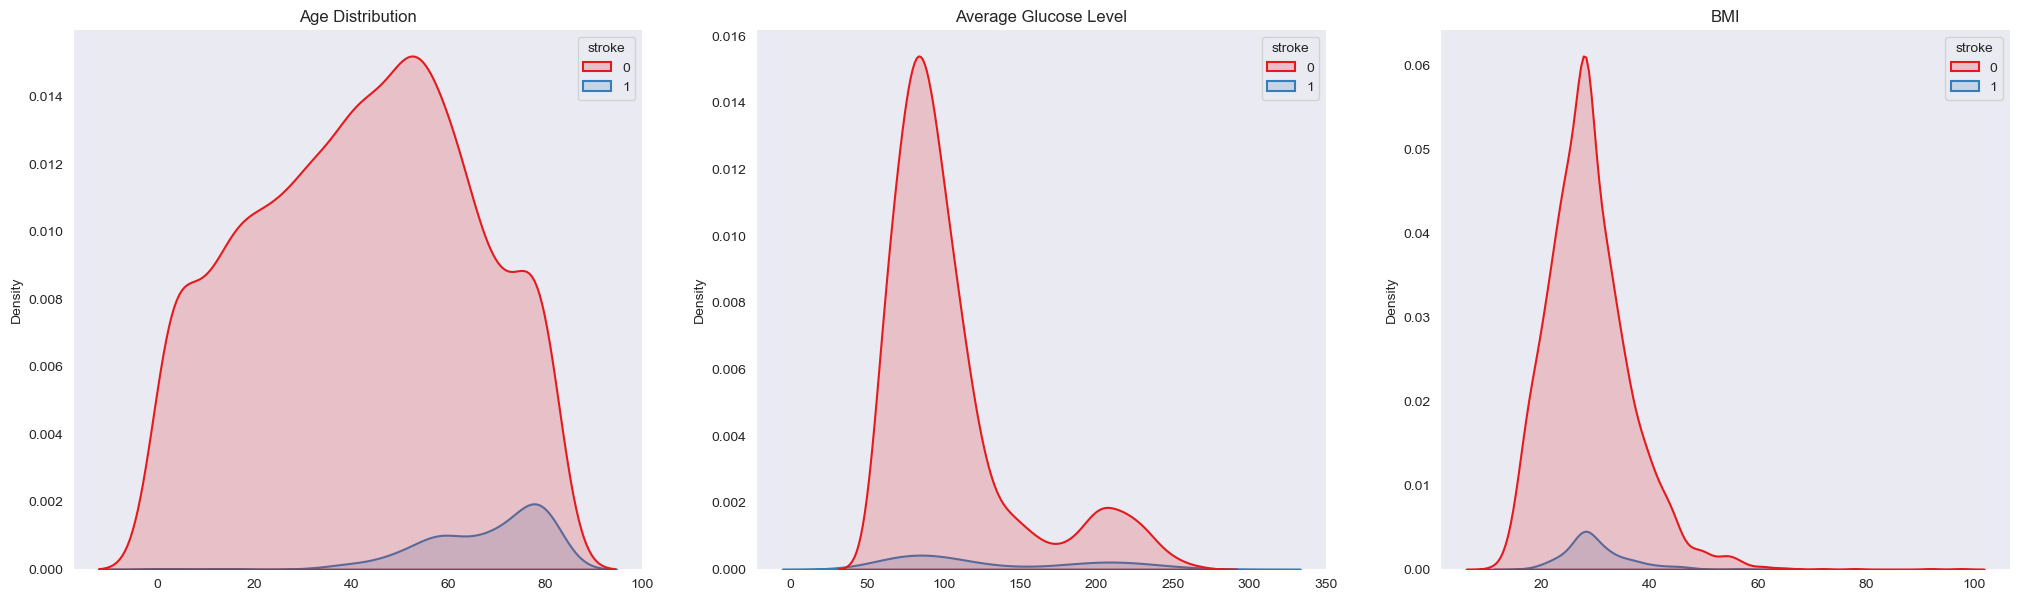

In [14]:
sns.set_style('dark')

plt.figure(figsize=(25,7))

plt.subplot(1,3,1)
sns.kdeplot(x=df['age'], alpha=0.2, palette="Set1", label='Smoker', data =df, fill=True, linewidth=1.5, hue=df['stroke']);
sns.despine(fig=None, ax=None, top=True, right=True, left=True, bottom=True, offset=None, trim=False);
plt.xlabel('');
plt.title('Age Distribution');

plt.subplot(1,3,2)
sns.kdeplot(x=df['avg_glucose_level'], alpha=0.2, palette="Set1", label='avg_glucose_level',linewidth=1.5, fill=True,hue=df['stroke']);
sns.despine(fig=None, ax=None, top=True, right=True, left=True, bottom=True, offset=None, trim=False);
plt.xlabel('');
plt.title('Average Glucose Level');

plt.subplot(1,3,3)
sns.kdeplot(x=df['bmi'], alpha=0.2, palette="Set1", label='BMI',data = df, shade=True, linewidth=1.5, fill=True, hue=df['stroke']);
sns.despine(fig=None, ax=None, top=True, right=True, left=False, bottom=True, offset=None, trim=False);
plt.xlabel('');
plt.title('BMI');

##### 1. Age Distribution Analysis

The age distribution was analyzed to understand its relationship with stroke occurrence. The density plot shows that individuals who experienced a stroke are predominantly concentrated in the older age groups, particularly between 60 and 85 years.

In contrast, individuals without stroke are distributed across a wider age range, with higher density between 30 and 60 years.

Key Insight

This pattern suggests a strong positive relationship between age and stroke risk, indicating that stroke probability increases significantly with age. Age is therefore expected to be one of the most influential predictors in the classification model.

#### 2. Average Glucose Level Distribution

The distribution of average glucose levels indicates a noticeable difference between stroke and non-stroke cases.

Individuals with stroke tend to exhibit higher glucose levels, with a secondary peak appearing around 200 mg/dL, while the majority of non-stroke individuals cluster around 80–120 mg/dL.

Key Insight

This suggests that elevated glucose levels may be associated with increased stroke risk, potentially reflecting underlying metabolic conditions such as diabetes.

##### 3. BMI Distribution

The BMI distributions for both stroke and non-stroke groups show significant overlap, with the majority of observations concentrated between 25 and 35.

While stroke cases appear slightly more concentrated around higher BMI values, the distinction between classes is not pronounced.

Key Insight

BMI alone does not strongly differentiate stroke and non-stroke cases, suggesting that its predictive power may be limited when used independently.

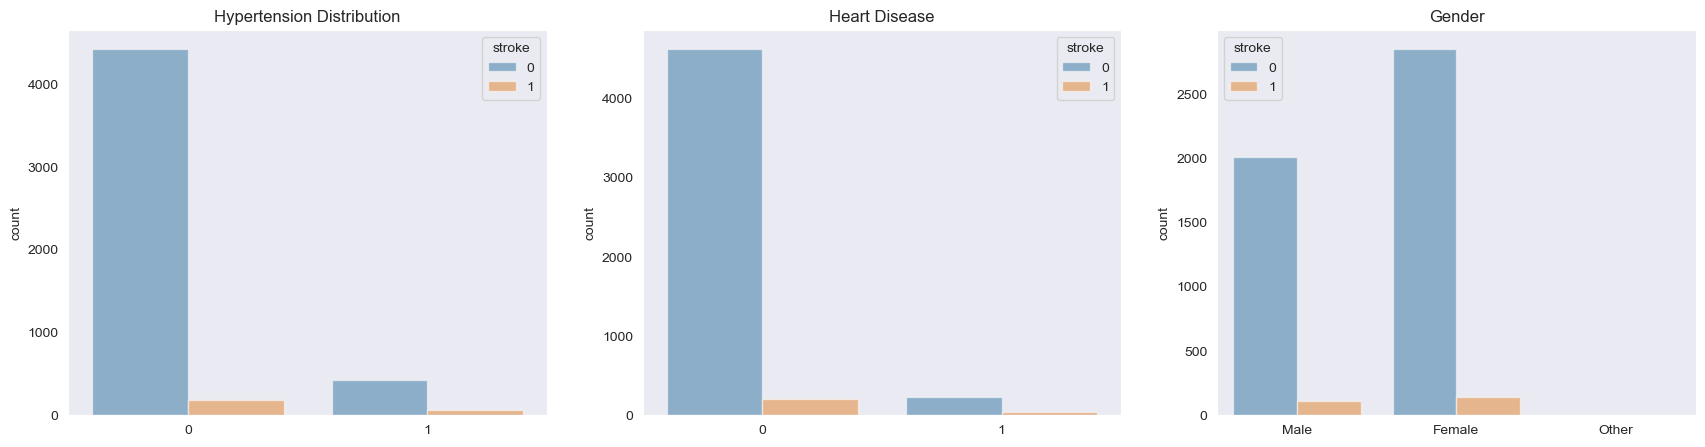

In [15]:
plt.figure(figsize=(21,5))
plt.subplot(1,3,1)
sns.countplot(data=df, x=df['hypertension'], alpha=0.5, hue=df['stroke'])
plt.xlabel('')
plt.title('Hypertension Distribution')


plt.subplot(1,3,2)
sns.countplot(data=df, x=df['heart_disease'], alpha=0.5, hue=df['stroke'])
plt.xlabel('')
plt.title('Heart Disease')

plt.subplot(1,3,3)
sns.countplot(data=df, x=df['gender'], alpha=0.5, hue=df['stroke'])
plt.xlabel('')
plt.title('Gender')

plt.show()

#### Hypertension

The distribution of hypertension indicates that the majority of individuals in the dataset do not have hypertension. However, when comparing stroke outcomes, individuals with hypertension show a relatively higher proportion of stroke cases compared to those without hypertension. This suggests a positive association between hypertension and stroke occurrence, aligning with established medical knowledge that hypertension is a major risk factor for stroke.

#### Heart Disease

Similar to hypertension, most individuals in the dataset do not have heart disease. Nevertheless, the proportion of stroke cases is noticeably higher among individuals with heart disease compared to those without it. This indicates that heart disease may significantly increase the likelihood of stroke, making it an important feature for predictive modeling.

#### Gender

The dataset contains more female participants than male participants. Stroke cases are present in both genders with relatively similar proportions. Based on the observed distribution, gender does not appear to exhibit a strong direct association with stroke occurrence in this dataset.


Overall, hypertension and heart disease demonstrate clearer associations with stroke occurrence compared to gender. These variables are likely to play an important role in predictive modeling, while gender may have a weaker predictive contribution based on the current exploratory analysis.

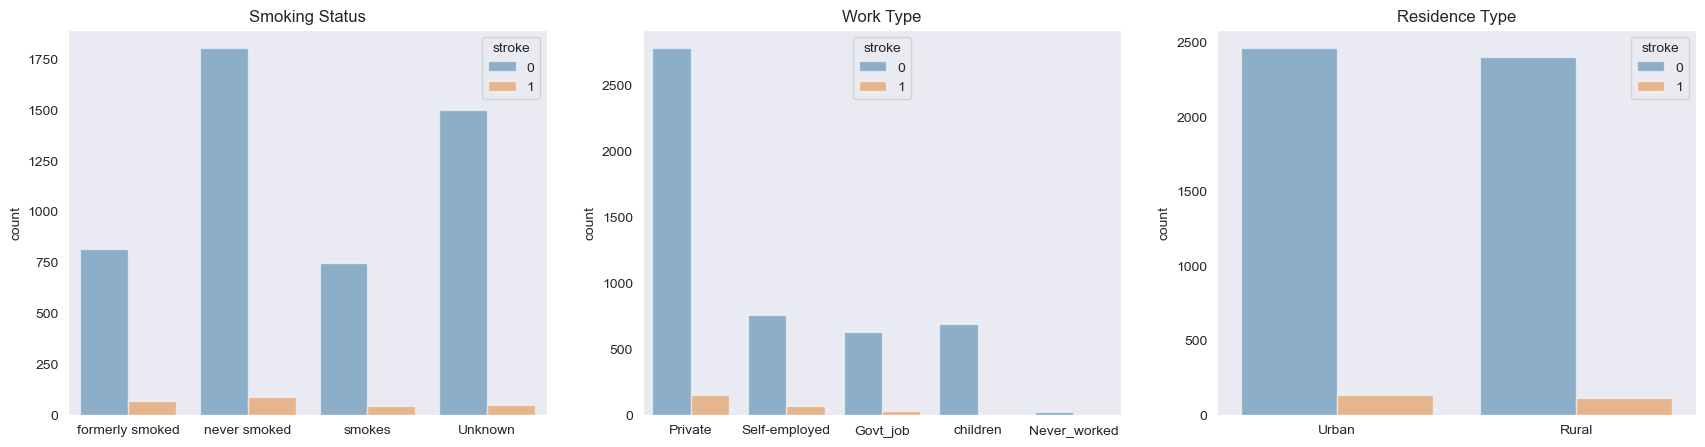

In [16]:
plt.figure(figsize=(21,5))
plt.subplot(1,3,1)
sns.countplot(data=df, x=df['smoking_status'], alpha=0.5, hue=df['stroke'])
plt.xlabel('')
plt.title('Smoking Status')


plt.subplot(1,3,2)
sns.countplot(data=df, x=df['work_type'], alpha=0.5, hue=df['stroke'])
plt.xlabel('')
plt.title('Work Type')

plt.subplot(1,3,3)
sns.countplot(data=df, x=df['Residence_type'], alpha=0.5, hue=df['stroke'])
plt.xlabel('')
plt.title('Residence Type')

plt.show()

#### 1. Smoking Status and Stroke Occurrence

The distribution of stroke cases across different smoking categories was examined to understand the relationship between smoking behavior and stroke incidence.

From the visualization, the majority of individuals belong to the "never smoked" category, followed by the "unknown" smoking status group. The categories "formerly smoked" and "smokes" contain comparatively fewer observations.

Across all smoking groups, non-stroke cases significantly outnumber stroke cases, indicating a strong class imbalance in the dataset.

However, a relatively higher proportion of stroke cases appears among individuals who formerly smoked, which could be explained by the possibility that many individuals stop smoking after developing health complications. Current smokers also exhibit stroke cases, though the proportion appears slightly lower relative to former smokers.

The "unknown" category introduces uncertainty, as it may contain both smokers and non-smokers, potentially adding noise to the analysis.

Insight

Smoking behavior may contribute to stroke risk, but its effect is likely moderate compared to stronger medical factors such as age, hypertension, and heart disease.

##### 2. Work Type and Stroke Occurrence

The distribution of stroke cases across different work categories was also analyzed.

The private sector category dominates the dataset, accounting for the largest number of individuals, followed by self-employed and government job categories. The children and never worked categories contain very few stroke cases.

This pattern is expected because stroke risk increases significantly with age, and the "children" category naturally represents younger individuals who have a much lower probability of experiencing stroke.

Similarly, individuals in private and self-employed categories likely represent the adult working population, which explains the higher number of stroke occurrences in these groups.

Insight

Work type itself is unlikely to be a direct cause of stroke. Instead, it likely acts as a proxy variable for age and socioeconomic factors.

#### 3. Residence Type and Stroke Occurrence

The relationship between residence type (urban vs rural) and stroke occurrence was examined.

The dataset shows nearly equal representation of individuals from urban and rural areas. Stroke cases are also distributed relatively evenly between these two groups.

Although urban areas show a slightly higher number of stroke cases, this difference is minimal and may simply reflect population distribution rather than a strong underlying relationship.

Insight

Residence type appears to have limited predictive power for stroke occurrence compared to health-related variables.

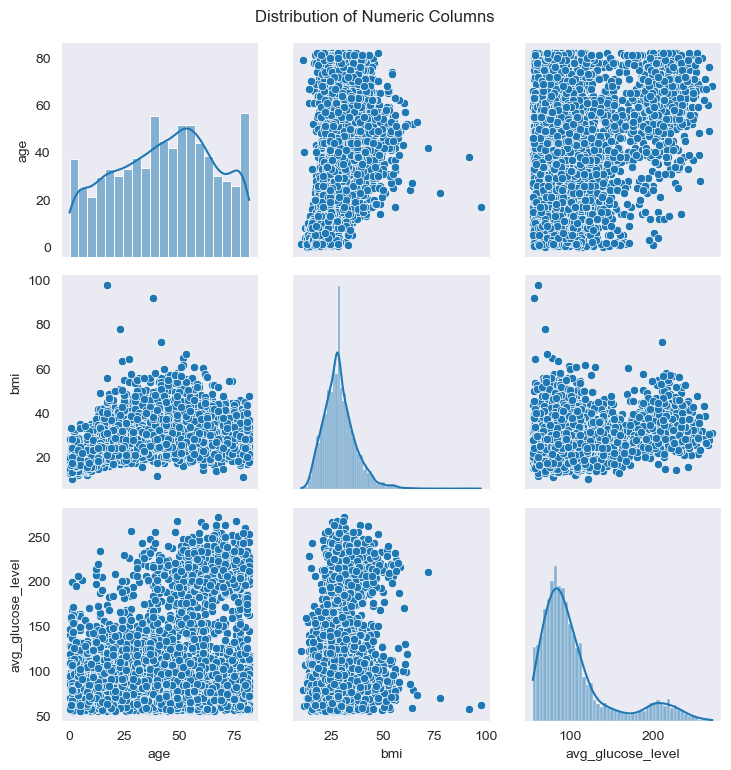

In [17]:
cols = ['age', 'bmi', 'avg_glucose_level']

g = sns.PairGrid(df[cols])
g.map_diag(sns.histplot, kde=True) 
g.map_offdiag(sns.scatterplot)  
g.fig.suptitle("Distribution of Numeric Columns", y=1.02)
plt.show()

###### 
Age: The distribution is fairly spread from 0 to about 80, with a higher concentration around middle age (40–60).

BMI: The distribution is approximately normal, centered around 27–30, with most values between 20 and 35 and a few outliers.

Average Glucose Level: The distribution is right-skewed, with most values between 70 and 120, and a noticeable spike at higher values (~170).

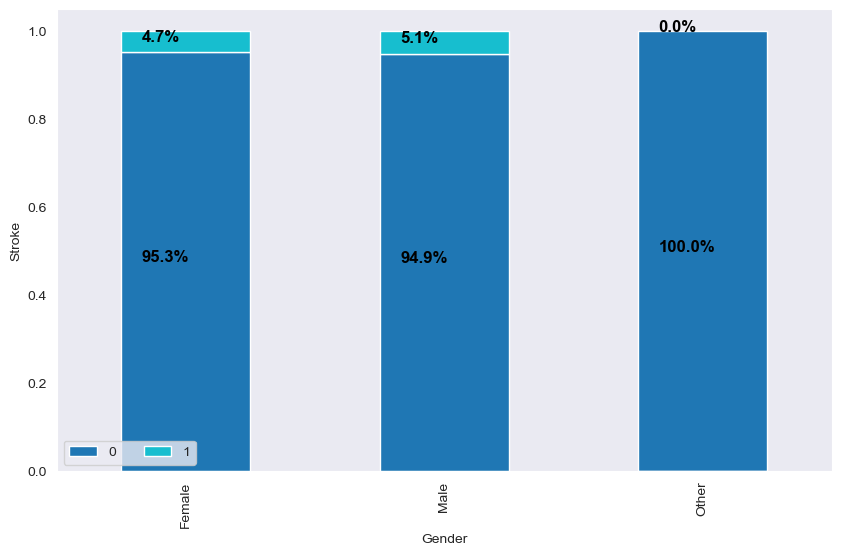

In [18]:
cross_tab = pd.crosstab(index=df['gender'],  columns=df['stroke'],normalize="index")
cross_tab

cross_tab.plot(kind='bar', stacked=True, colormap='tab10', figsize=(10, 6))

plt.legend(loc="lower left", ncol=2)
plt.xlabel("Gender")
plt.ylabel("Stroke")

for n, x in enumerate([*cross_tab.index.values]):
    for (proportion, y_loc) in zip(cross_tab.loc[x], cross_tab.loc[x].cumsum()):
                
        plt.text(x=n - 0.17,
                 y=(y_loc - proportion) + (proportion / 2),
                 s=f'{np.round(proportion * 100, 1)}%', 
                 color="black",
                 fontsize=12,
                 fontweight="bold")

plt.show()

###### Higher stroke cases in males than females (in terms of proportion)

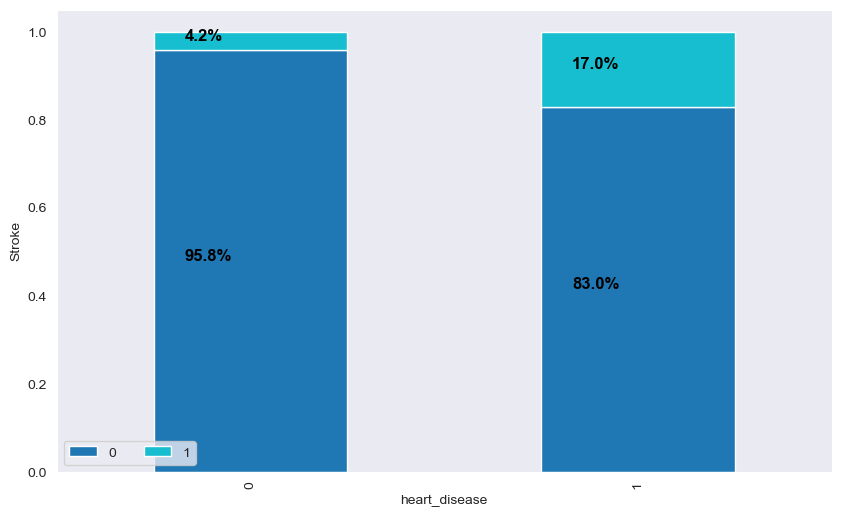

In [19]:
cross_tab = pd.crosstab(index=df['heart_disease'],columns=df['stroke'],normalize="index")
cross_tab

cross_tab.plot(kind='bar', stacked=True, colormap='tab10', figsize=(10, 6))

plt.legend(loc="lower left", ncol=2)
plt.xlabel("heart_disease")
plt.ylabel("Stroke")

for n, x in enumerate([*cross_tab.index.values]):
    for (proportion, y_loc) in zip(cross_tab.loc[x], cross_tab.loc[x].cumsum()):
                
        plt.text(x=n - 0.17,
                 y=(y_loc - proportion) + (proportion / 2),
                 s=f'{np.round(proportion * 100, 1)}%', 
                 color="black",
                 fontsize=12,
                 fontweight="bold")

plt.show()

###### As expected, people with heart disease are more likely to have stroke.

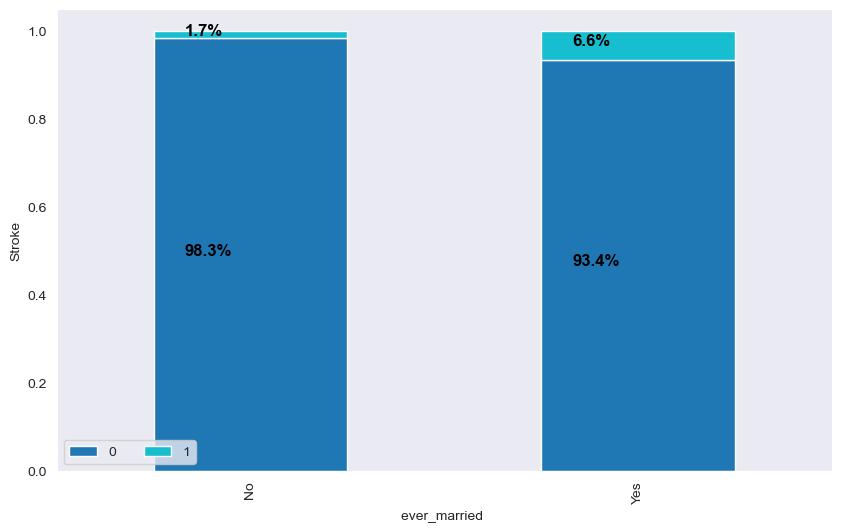

In [20]:
cross_tab = pd.crosstab(index=df['ever_married'],columns=df['stroke'],normalize="index")
cross_tab

cross_tab.plot(kind='bar', stacked=True, colormap='tab10', figsize=(10, 6))

plt.legend(loc="lower left", ncol=2)
plt.xlabel("ever_married ")
plt.ylabel("Stroke")

for n, x in enumerate([*cross_tab.index.values]):
    for (proportion, y_loc) in zip(cross_tab.loc[x],cross_tab.loc[x].cumsum()):
                
        plt.text(x=n - 0.17,
                 y=(y_loc - proportion) + (proportion / 2),
                 s=f'{np.round(proportion * 100, 1)}%', 
                 color="black",
                 fontsize=12,
                 fontweight="bold")

plt.show()

##### Higher stroke percentage is found in people who got married

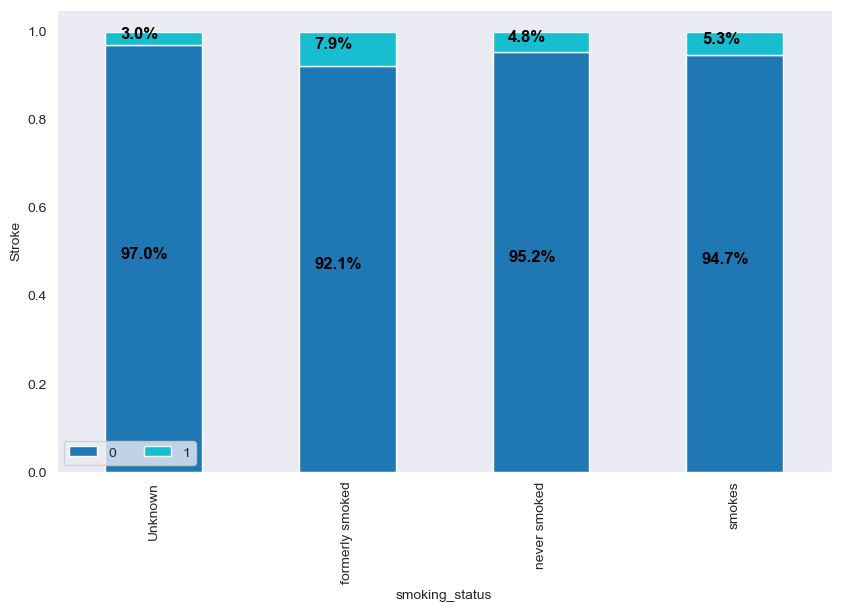

In [21]:
cross_tab = pd.crosstab(index=df['smoking_status'],columns=df['stroke'],normalize="index")
cross_tab

cross_tab.plot(kind='bar', stacked=True, colormap='tab10', figsize=(10, 6))

plt.legend(loc="lower left", ncol=2)
plt.xlabel("smoking_status")
plt.ylabel("Stroke")

for n, x in enumerate([*cross_tab.index.values]):
    for (proportion, y_loc) in zip(cross_tab.loc[x],
                                   cross_tab.loc[x].cumsum()):
                
        plt.text(x=n - 0.17,
                 y=(y_loc - proportion) + (proportion / 2),
                 s=f'{np.round(proportion * 100, 1)}%', 
                 color="black",
                 fontsize=12,
                 fontweight="bold")

plt.show()

###### As expected, people who smoke or formerly smoked have more cases of stroke.

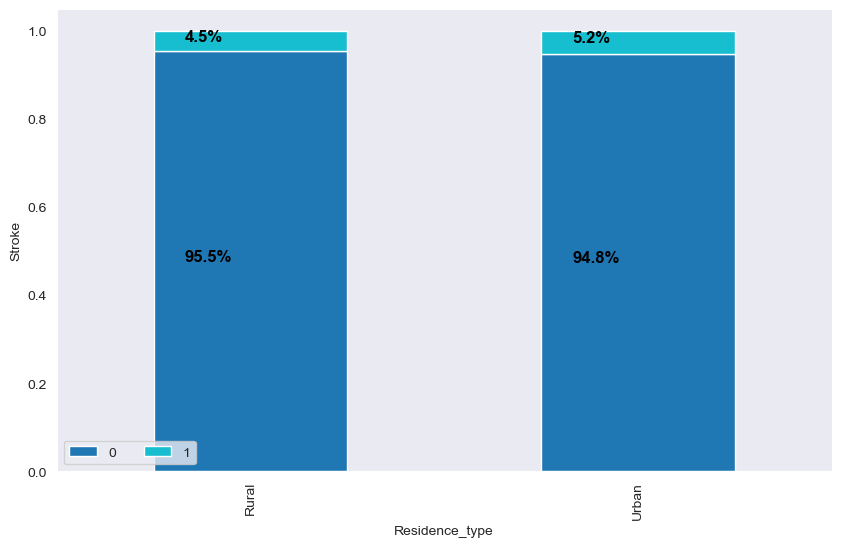

In [22]:
cross_tab = pd.crosstab(index=df['Residence_type'],  columns=df['stroke'], normalize="index")
cross_tab

cross_tab.plot(kind='bar', stacked=True,  colormap='tab10',  figsize=(10, 6))

plt.legend(loc="lower left", ncol=2)
plt.xlabel("Residence_type")
plt.ylabel("Stroke")

for n, x in enumerate([*cross_tab.index.values]):
    for (proportion, y_loc) in zip(cross_tab.loc[x],cross_tab.loc[x].cumsum()):
                
        plt.text(x=n - 0.17,
                 y=(y_loc - proportion) + (proportion / 2),
                 s=f'{np.round(proportion * 100, 1)}%', 
                 color="black",
                 fontsize=12,
                 fontweight="bold")

plt.show()

###### People in urban areas are more likely to have stroke as compared to the rural areas.

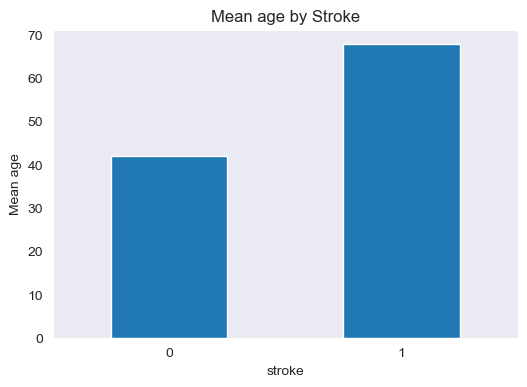

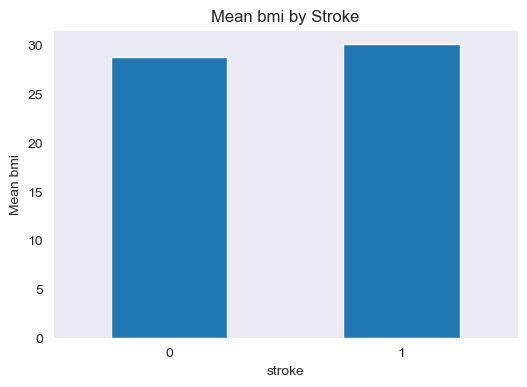

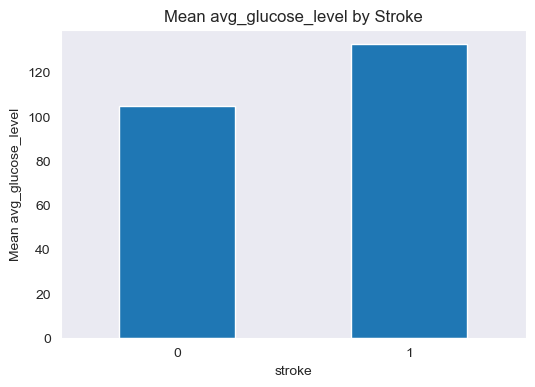

In [23]:
for col in cols:
    grouped_data = df.groupby("stroke")[col].mean()
    
    grouped_data.plot(kind='bar', figsize=(6, 4), title=f'Mean {col} by Stroke')
    plt.ylabel(f'Mean {col}')
    plt.xticks(rotation=0) # Keeps labels flat
    plt.show()

###### As seen above, the risk of having a stroke increases with significantly with age but slightly glucose level and bmi

In [24]:
def convert_to_buckets(avg_glucose_level):
    if avg_glucose_level < 70:
        return "Low glucose (hypoglycemia)"
    elif 70 <= avg_glucose_level <= 99:
        return "Normal glucose"
    elif 100 <= avg_glucose_level <= 125:
        return "Prediabetes"
    else:  
        return "High glucose (Diabetes)"

df['avg_glucose_class'] = df['avg_glucose_level'].map(convert_to_buckets)
df['avg_glucose_class'].value_counts()

Normal glucose                2317
High glucose (Diabetes)       1060
Prediabetes                    979
Low glucose (hypoglycemia)     754
Name: avg_glucose_class, dtype: int64

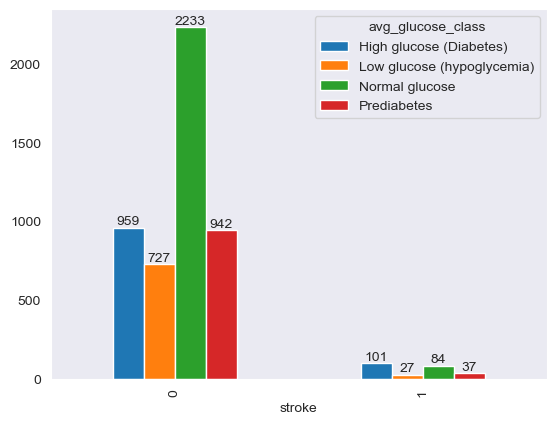

In [25]:
mglucose_level = df.groupby('stroke')['avg_glucose_class'].value_counts().unstack()

ax = mglucose_level.plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container)

plt.show()

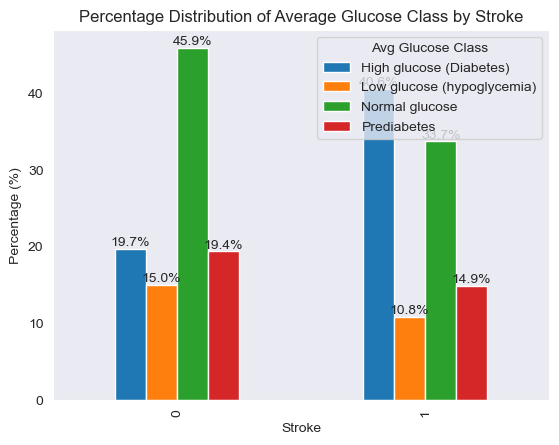

In [26]:
mglucose_level_pct = (df.groupby('stroke')['avg_glucose_class'].value_counts(normalize=True) .mul(100) .unstack())
mglucose_level_pct.plot(kind='bar')

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f%%')

plt.title('Percentage Distribution of Average Glucose Class by Stroke')
plt.ylabel('Percentage (%)')
plt.xlabel('Stroke')
plt.legend(title='Avg Glucose Class')
plt.show()

#### Most individuals are in the no-stroke (0) group across all glucose classes. 

Normal glucose dominates: 
The largest portion of the dataset has normal glucose levels (~45.9% without stroke, ~33.7% with stroke). 

Higher stroke proportion in high glucose group: 
The high glucose (diabetes) category shows a relatively higher share among stroke cases 40.6% compared to its share in non-stroke cases (~19.7%). Suggests a possible association between high glucose and stroke risk. 

Low glucose least common: 
Hypoglycemia has the smallest counts in both stroke and non-stroke groups. 

Prediabetes moderate presence: 
Prediabetes appears moderately in both groups but lower in stroke cases (14.9%) compared to non-stroke (19.4%). 

Overall insight: Stroke cases show a higher concentration of high glucose (diabetes) and a lower share of normal glucose, indicating that elevated glucose levels may be linked with increased stroke risk. 

 

In [27]:
def convert_to_buckets(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal Weight'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].map(convert_to_buckets)

print(df['bmi_category'].value_counts())

Obese            1920
Overweight       1610
Normal Weight    1243
Underweight       337
Name: bmi_category, dtype: int64


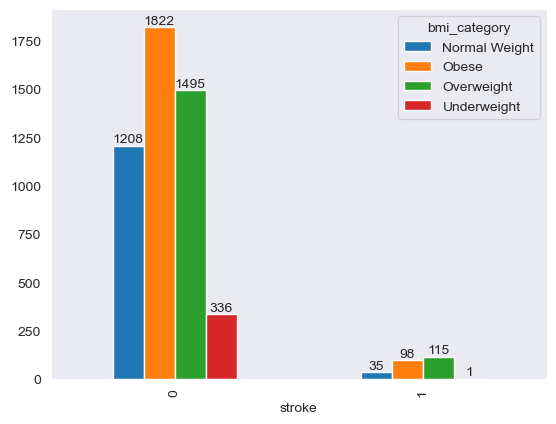

In [28]:
bmi_group = df.groupby('stroke')['bmi_category'].value_counts().unstack()

ax = bmi_group.plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

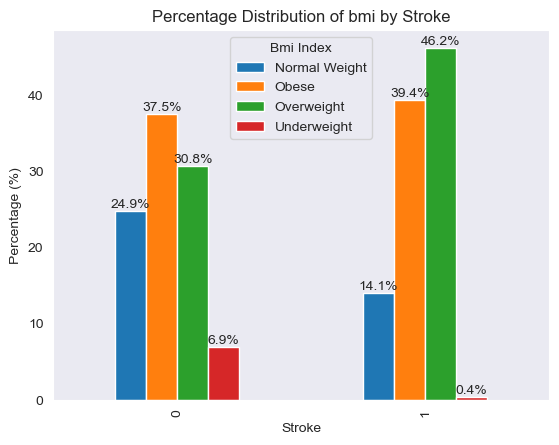

In [29]:
bmi_group = (df.groupby('stroke')['bmi_category'].value_counts(normalize=True) .unstack() * 100)
bmi_group.plot(kind='bar')

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f%%')

plt.title('Percentage Distribution of bmi by Stroke')
plt.ylabel('Percentage (%)')
plt.xlabel('Stroke')
plt.legend(title='Bmi Index')
plt.show()


##### People with stroke show a clear shift toward higher BMI categories:
Overweight — most common (46.2%),
Obese — also very high (39.4%),
Normal weight — much lower (14.1%),
Underweight — almost negligible (0.4%),

##### People without stroke have a different pattern:
Obese — highest proportion (37.5%),
Overweight — substantial (30.8%),
Normal weight — notable (24.8%),
Underweight — still present (6.9%)

#### Key takeaway:
Stroke is strongly associated with higher BMI — overweight and obese categories dominate among people who had a stroke (85.6% combined), while underweight and normal weight are rare. In contrast, the non-stroke group shows a broader spread, with a larger share of normal-weight individuals and still-significant underweight representation. This suggests elevated BMI (especially overweight/obese) is linked to increased stroke occurrence in the dataset.

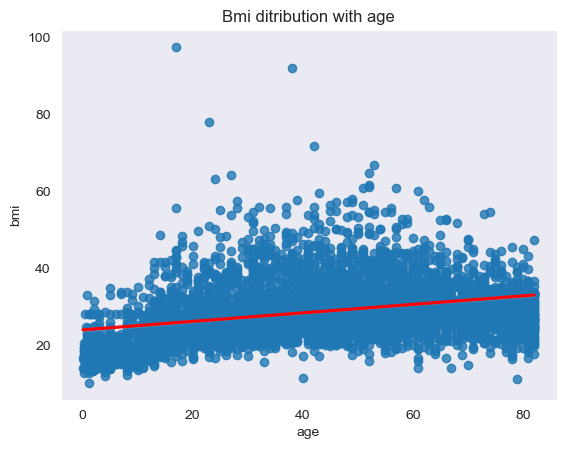

In [30]:
sns.regplot(x='age', y = 'bmi', data = df, line_kws={"color":"red"})
plt.title("Bmi ditribution with age")
plt.show()

###### The visualization suggests a slight positive relationship between age and BMI, as indicated by the upward slope of the regression line. This implies that, on average, BMI tends to increase as individuals get older

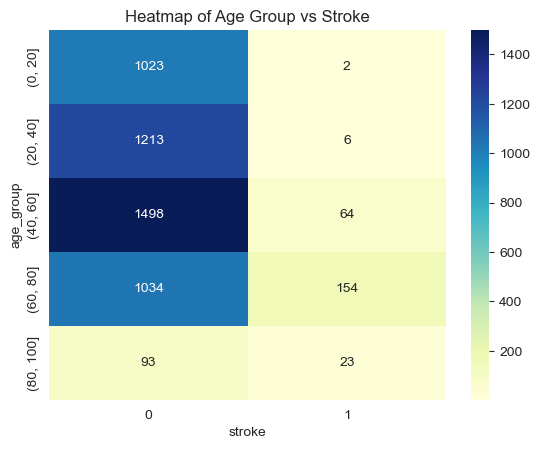

In [31]:
df["age_group"] = pd.cut(df["age"],
                           bins=[0,20,40,60,80,100])

table_data = pd.crosstab(df["age_group"], df["stroke"])

sns.heatmap(table_data, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Heatmap of Age Group vs Stroke")
plt.show()

##### Main Insight
The risk of stroke increases dramatically with age from practically negligible (<0.5%) in people under 40 to ~13% in the 60–80 group and nearly 20% in those over 80. This pattern aligns with well-established medical knowledge that age is one of the strongest non-modifiable risk factors for stroke.
Overall, the heatmap reveals a strong positive relationship between age and stroke occurrence. Stroke cases increase steadily with age, particularly after the age of 40, and become significantly more common among individuals aged 60 and above. This finding suggests that age is a key factor influencing the likelihood of stroke, making it an important variable for further analysis and predictive modeling.

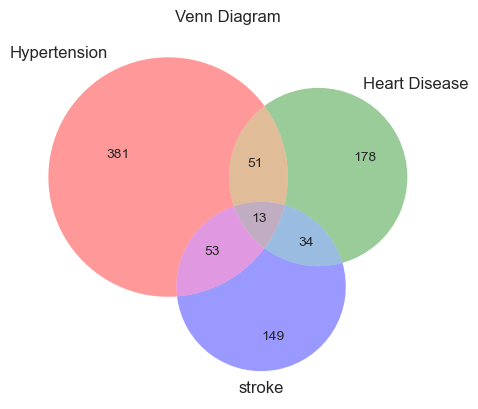

In [32]:
hypertension = set(df[df['hypertension']== 1].index)
heart_disease = set(df[df['heart_disease']== 1].index)
stroke = set(df[df['stroke'] == 1].index)

venn3([hypertension, heart_disease, stroke],set_labels=('Hypertension', 'Heart Disease','stroke'))
plt.title("Venn Diagram")
plt.show()

#####  Insight
Hypertension has the highest number of cases (381 people with only hypertension).

Heart Disease has 178 cases alone, while Stroke has 149 cases alone.

Some individuals have two conditions:

Hypertension & Heart Disease: 51

Hypertension & Stroke: 53

Heart Disease & Stroke: 34

13 people have all three conditions.

Hypertension overlaps the most with the other conditions, suggesting it is a major risk factor for both heart disease and stroke.

##### Checking for outliers

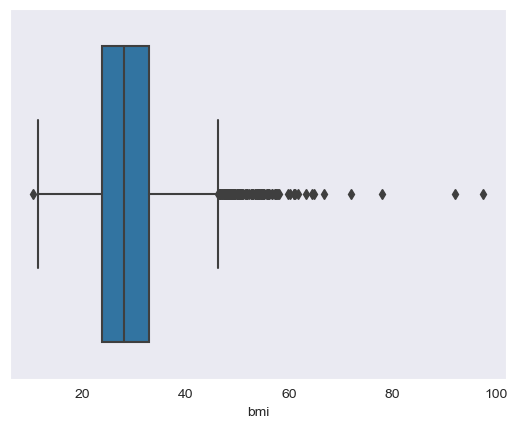

In [33]:
sns.boxplot(x=df['bmi'],data=df)
plt.show()

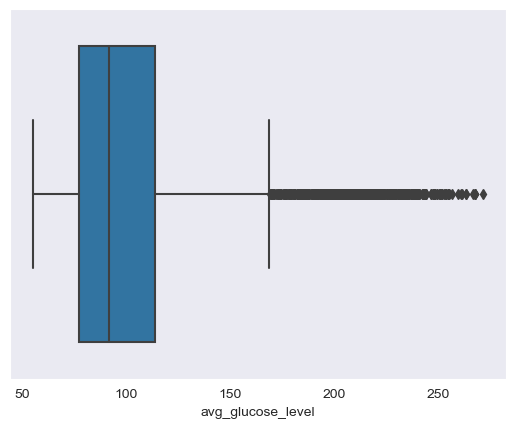

In [34]:
sns.boxplot(x=df['avg_glucose_level'],data=df)
plt.show()

In [35]:
num_cols = [col for col in df.columns if df[col].dtypes in ["float64"]]
def check_outliers(df, num_cols, low_threshold=0.25, up_threshold=0.75):
    outlier_cols = []
    for col in num_cols:
        q1 = df[col].quantile(low_threshold)
        q3 = df[col].quantile(up_threshold)
        interquantile = q3 - q1
        up_limit = q3 + 1.5 * interquantile
        low_limit = q1 - 1.5 * interquantile
        if df[(df[col] > up_limit) | (df[col] < low_limit)].any(axis=None):
            outlier_cols.append(col)
    if not outlier_cols:
        print("There is no outliers")
    return outlier_cols

In [36]:
outlier_cols = check_outliers(df, num_cols)
print(outlier_cols)

['avg_glucose_level', 'bmi']


##### Filling outliers with the upper and lower whisker where necessary

In [37]:
def replace_with_thresholds(df, col, low_threshold=0.25, up_threshold=0.75):
    q1 = df[col].quantile(low_threshold)
    q3 = df[col].quantile(up_threshold)
    interquantile = q3 - q1
    up_limit = q3 + 1.5 * interquantile
    low_limit = q1 - 1.5 * interquantile
    df.loc[(df[col] < low_limit), col] = low_limit
    df.loc[(df[col] > up_limit), col] = up_limit

In [38]:
for col in outlier_cols:
    replace_with_thresholds(df, col)

In [39]:
check_outliers(df, num_cols)

There is no outliers


[]

In [40]:
# removing the 'Other' rows from the gender column
print(f"Shape before removing 'Other': {df.shape}")
df = df[df['gender'] != 'Other']
print(f"Shape after removing 'Other':{df.shape}")

Shape before removing 'Other': (5110, 14)
Shape after removing 'Other':(5109, 14)


In [41]:
# split Dataset into dependent and independent varaibles
x = df.drop(columns=['stroke','avg_glucose_class','bmi_category','age_group'])
y = df['stroke']

In [42]:
x.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Male,67.0,0,1,Yes,Private,Urban,169.3575,36.6,formerly smoked
1,Female,61.0,0,0,Yes,Self-employed,Rural,169.3575,28.1,never smoked
2,Male,80.0,0,1,Yes,Private,Rural,105.9200,32.5,never smoked
3,Female,49.0,0,0,Yes,Private,Urban,169.3575,34.4,smokes
4,Female,79.0,1,0,Yes,Self-employed,Rural,169.3575,24.0,never smoked


In [43]:
x.shape

(5109, 10)

In [44]:
y.shape

(5109,)

### FEATURE ENCODING

In [45]:
cat_cols = x.select_dtypes(include=['object']).columns.tolist()
cat_cols

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

In [46]:
Le = LabelEncoder()
for col in cat_cols:
    x[col] = Le.fit_transform(x[col])

In [47]:
x.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,1,67.0,0,1,1,2,1,169.3575,36.6,1
1,0,61.0,0,0,1,3,0,169.3575,28.1,2
2,1,80.0,0,1,1,2,0,105.9200,32.5,2
3,0,49.0,0,0,1,2,1,169.3575,34.4,3
4,0,79.0,1,0,1,3,0,169.3575,24.0,2


### FEATURE CORRELATION

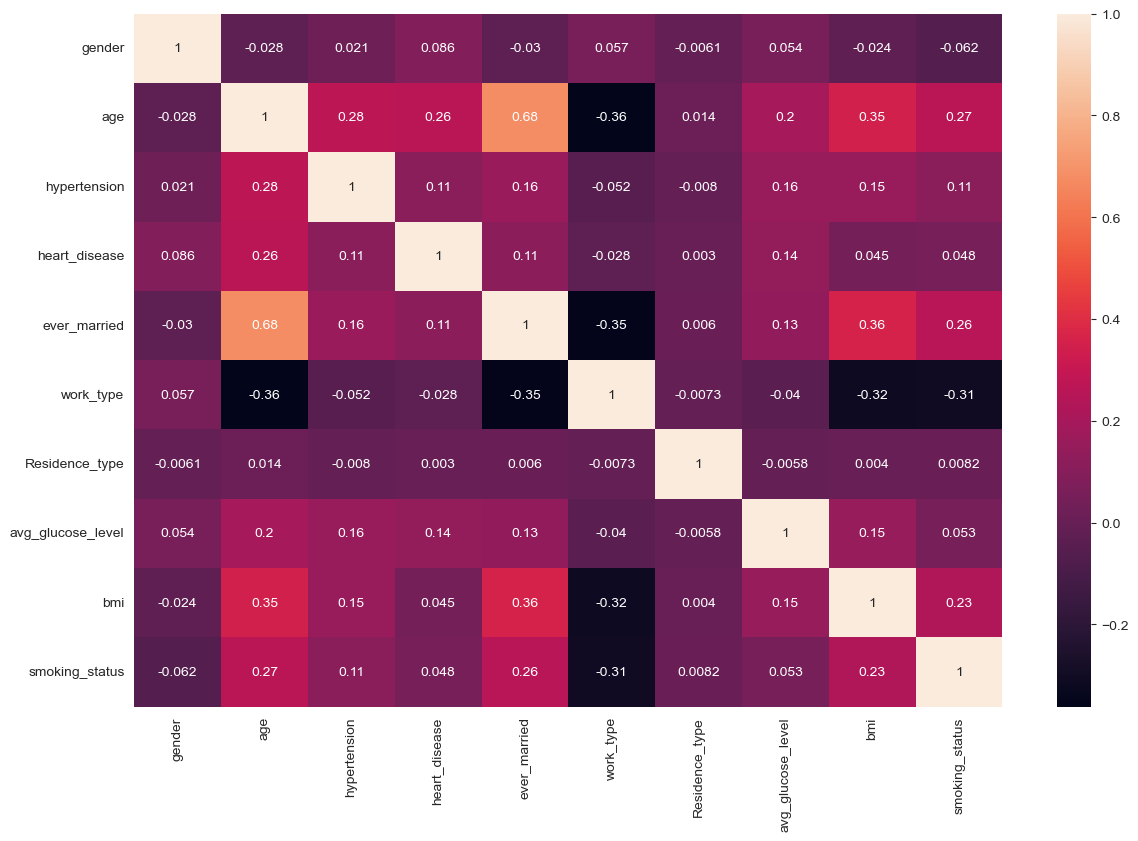

In [48]:
plt.figure(figsize=(14,9))
sns.heatmap(x.corr(), annot=True)
plt.show()

#####  Correlation Heatmap Analysis
A correlation heatmap was used to visualize the relationships between different features in the dataset. The heatmap represents Pearson correlation coefficients ranging from -1 to +1, where values closer to +1 indicate strong positive correlation and values closer to -1 indicate strong negative correlation. From the analysis, age shows a relatively strong positive correlation with ever_married (0.68) and moderate correlations with hypertension, heart disease, and BMI, indicating that these health factors tend to increase with age. Some moderate negative correlations are observed between work_type and age (-0.36) and work_type and ever_married (-0.35), likely due to categorical encoding. Overall, most variables show weak correlations, indicating low multicollinearity and making the dataset suitable for machine learning modeling.A correlation heatmap was used to visualize the relationships between different features in the dataset. The heatmap represents Pearson correlation coefficients ranging from -1 to +1, where values closer to +1 indicate strong positive correlation and values closer to -1 indicate strong negative correlation. From the analysis, age shows a relatively strong positive correlation with ever_married (0.68) and moderate correlations with hypertension, heart disease, and BMI, indicating that these health factors tend to increase with age. Some moderate negative correlations are observed between work_type and age (-0.36) and work_type and ever_married (-0.35), likely due to categorical encoding. Overall, most variables show weak correlations, indicating low multicollinearity and making the dataset suitable for machine learning modeling.

### FEATURE SCALING

In [49]:
scaler = StandardScaler()
scaledX = scaler.fit_transform(x)

scaledX

array([[ 1.18979109,  1.05124201, -0.32863749, ...,  2.05873841,
         1.11067539, -0.3518194 ],
       [-0.84048369,  0.78588869, -0.32863749, ...,  2.05873841,
        -0.08309215,  0.58143361],
       [ 1.18979109,  1.6261742 , -0.32863749, ...,  0.14851439,
         0.53485811,  0.58143361],
       ...,
       [-0.84048369, -0.3639757 , -0.32863749, ..., -0.54195161,
         0.26801595,  0.58143361],
       [ 1.18979109,  0.34363316, -0.32863749, ...,  1.96637013,
        -0.43420025, -0.3518194 ],
       [-0.84048369,  0.03405428, -0.32863749, ..., -0.47299534,
        -0.3499343 , -1.28507241]])

In [50]:
y.value_counts()

0    4860
1     249
Name: stroke, dtype: int64

### TRAIN-TEST-SPLIT

In [51]:
x_train, x_test, y_train, y_test = train_test_split(scaledX, y, test_size=0.2, random_state=32)

### TRAINING & TESTING 

In [52]:
LR = LogisticRegression()
KNN = KNeighborsClassifier()
DecisionTree = DecisionTreeClassifier()
RFC = RandomForestClassifier()
SVM = SVC()
GBC = GradientBoostingClassifier()
XGBoost = XGBClassifier()

#### CROSS VALIDATION OF BASE MODELS

In [53]:
# create a list with the models
models= [LR, KNN, DecisionTree, RFC,SVM,GBC, XGBoost]
for model in models:
    scores = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')
    print(model)
    print(f'mean accuracy : {scores.mean()}')
    print(f'scores: {scores}\n')

LogisticRegression()
mean accuracy : 0.9515539288888624
scores: [0.95110024 0.95110024 0.95226438 0.95226438 0.95104039]

KNeighborsClassifier()
mean accuracy : 0.9491065470009247
scores: [0.94987775 0.94987775 0.9498164  0.94736842 0.94859241]

DecisionTreeClassifier()
mean accuracy : 0.9065365266808918
scores: [0.89119804 0.90709046 0.90208078 0.91799266 0.91432069]

RandomForestClassifier()
mean accuracy : 0.9498412403898813
scores: [0.94987775 0.94865526 0.95104039 0.94859241 0.95104039]

SVC()
mean accuracy : 0.9513091308472467
scores: [0.95110024 0.95110024 0.95226438 0.95104039 0.95104039]

GradientBoostingClassifier()
mean accuracy : 0.9473947562942724
scores: [0.94621027 0.94621027 0.94859241 0.94492044 0.95104039]

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature

In [54]:
for model in models:
    model.fit(x_train, y_train) # fit the model
    y_pred= model.predict(x_test) # then predict on the test set
    accuracy= accuracy_score(y_test, y_pred) # this gives us how often the algorithm predicted correctly
    clf_report= classification_report(y_test, y_pred) # with the report, we have a bigger picture, with precision and recall for each class
    cm = confusion_matrix(y_test, y_pred)
    print(f"The accuracy of model {type(model).__name__} is {accuracy:.2f}")
    print(clf_report)
    print(cm)
    print("\n")

The accuracy of model LogisticRegression is 0.95
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

[[972   0]
 [ 50   0]]


The accuracy of model KNeighborsClassifier is 0.95
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       0.67      0.04      0.08        50

    accuracy                           0.95      1022
   macro avg       0.81      0.52      0.53      1022
weighted avg       0.94      0.95      0.93      1022

[[971   1]
 [ 48   2]]


The accuracy of model DecisionTreeClassifier is 0.91
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       972
           1       0.17      0.20 

###### Using smote to balance the training dataset

In [55]:
sm = SMOTE()

In [56]:
sum(y_train == 1) 

199

In [57]:
sum(y_train == 0)

3888

In [58]:
X_train_smote, y_train_smote = sm.fit_resample(x_train, y_train)

In [59]:
sum(y_train_smote == 1) 

3888

In [60]:
sum(y_train_smote == 0)

3888

##### Cross validation

In [61]:
for model in models:
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring='accuracy')
    print(model)
    print(f'mean accuracy : {scores.mean()}')
    print(f'scores: {scores}\n')

LogisticRegression()
mean accuracy : 0.7881962158721761
scores: [0.77442159 0.80450161 0.79614148 0.78649518 0.77942122]

KNeighborsClassifier()
mean accuracy : 0.903806693723704
scores: [0.9029563  0.9073955  0.9022508  0.89903537 0.9073955 ]

DecisionTreeClassifier()
mean accuracy : 0.9218165136098001
scores: [0.87660668 0.93826367 0.92733119 0.92926045 0.93762058]

RandomForestClassifier()
mean accuracy : 0.9623248662991097
scores: [0.92416452 0.9755627  0.97234727 0.96977492 0.96977492]

SVC()
mean accuracy : 0.8400220699460238
scores: [0.82840617 0.84501608 0.84694534 0.84308682 0.83665595]

GradientBoostingClassifier()
mean accuracy : 0.9205310839071243
scores: [0.87082262 0.94340836 0.93890675 0.9318328  0.91768489]

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_

In [62]:
models= [LR, KNN, DecisionTree, RFC,SVM,GBC, XGBoost]

for model in models:
    model.fit(X_train_smote, y_train_smote) # fit the model
    y_pred= model.predict(x_test) # then predict on the test set
    accuracy= accuracy_score(y_test, y_pred) # this gives us how often the algorithm predicted correctly
    clf_report= classification_report(y_test, y_pred) # with the report, we have a bigger picture, with precision and recall for each class
    cm = confusion_matrix(y_test, y_pred)
    print(f"The accuracy of model {type(model).__name__} is {accuracy:.2f}")
    print(clf_report)
    print(cm)
    print("\n")

The accuracy of model LogisticRegression is 0.74
              precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.14      0.82      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.78      0.54      1022
weighted avg       0.95      0.74      0.81      1022

[[711 261]
 [  9  41]]


The accuracy of model KNeighborsClassifier is 0.83
              precision    recall  f1-score   support

           0       0.96      0.85      0.90       972
           1       0.12      0.40      0.19        50

    accuracy                           0.83      1022
   macro avg       0.54      0.63      0.55      1022
weighted avg       0.92      0.83      0.87      1022

[[827 145]
 [ 30  20]]


The accuracy of model DecisionTreeClassifier is 0.89
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       972
           1       0.15      0.26 

#### HYPERPARAMETER TUNNING OF GradientBoostingClassifier()

In [63]:
GBC = GradientBoostingClassifier()

In [64]:
GBC.fit(X_train_smote, y_train_smote)

GradientBoostingClassifier()

In [65]:
y_pred = GBC.predict(x_test)

In [66]:
accuracy = accuracy_score(y_test, y_pred)
CLF = classification_report(y_test, y_pred)

In [67]:
print(accuracy)
print(CLF)

0.9021526418786693
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       972
           1       0.20      0.32      0.24        50

    accuracy                           0.90      1022
   macro avg       0.58      0.63      0.60      1022
weighted avg       0.93      0.90      0.91      1022



In [68]:
GBC.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': None,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [69]:
param_grid ={
    'n_estimators': [50, 100, 200, 400,800,1000],
    'learning_rate': [0.01,0.1,0.2, 0.4,0.8,1],
    'max_depth': [3,5,6,8,10,15],
    "subsample":[0.5, 0.618, 0.8, 0.85, 1],
    "criterion": ["friedman_mse",  "mae"],
    "max_features":["log2","sqrt"],
}

In [70]:
gbc = GradientBoostingClassifier()

In [71]:
grid_search = GridSearchCV(estimator = gbc, param_grid = param_grid, cv = 5, scoring = 'f1',refit=True, n_jobs=-1)

In [72]:
grid_search.fit(X_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'criterion': ['friedman_mse', 'mae'],
                         'learning_rate': [0.01, 0.1, 0.2, 0.4, 0.8, 1],
                         'max_depth': [3, 5, 6, 8, 10, 15],
                         'max_features': ['log2', 'sqrt'],
                         'n_estimators': [50, 100, 200, 400, 800, 1000],
                         'subsample': [0.5, 0.618, 0.8, 0.85, 1]},
             scoring='f1')

In [73]:
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(x_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
CLR = classification_report(y_test, y_pred_best)
cm = confusion_matrix(y_test, y_pred_best)

In [74]:
print("Best parameters :", best_params)
print(f"Best Model Accurarcy: {accuracy_best}")
print(CLF)
print(cm)

Best parameters : {'criterion': 'friedman_mse', 'learning_rate': 0.1, 'max_depth': 15, 'max_features': 'log2', 'n_estimators': 1000, 'subsample': 0.85}
Best Model Accurarcy: 0.9334637964774951
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       972
           1       0.20      0.32      0.24        50

    accuracy                           0.90      1022
   macro avg       0.58      0.63      0.60      1022
weighted avg       0.93      0.90      0.91      1022

[[948  24]
 [ 44   6]]


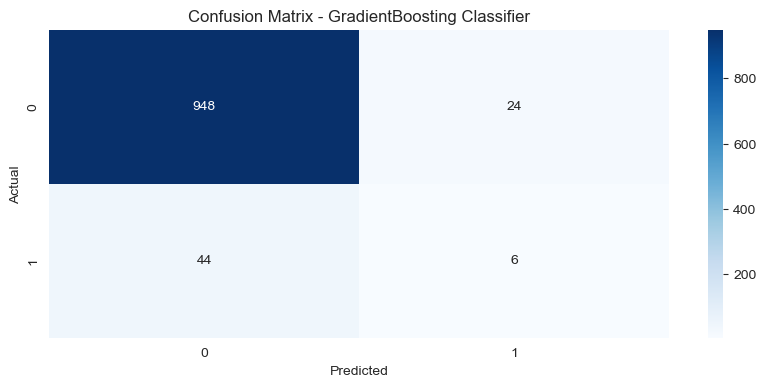

In [85]:
plt.figure(figsize=(10,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - GradientBoosting Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Insight
The performance of the classification model was evaluated using a confusion matrix. The model correctly classified 945 true negatives and 5 true positives, while 27 false positives and 45 false negatives were observed. The overall accuracy of the model was 93.0%. However, despite the high accuracy, the model demonstrated low sensitivity (10.0%), indicating that it failed to correctly identify a large proportion of positive cases. The precision of the model was 15.6%, suggesting that many of the predicted positive cases were incorrect. In contrast, the specificity was high (97.2%), indicating that the model was effective in identifying negative cases. These results suggest that although the model performs well in recognizing negative instances, it has limited ability to detect positive cases, likely due to class imbalance in the dataset.

### ROC Score

In [75]:
y_pred_prob = best_model.predict_proba(x_test)[:,1]
y_pred_prob

array([5.33273015e-09, 4.10303136e-09, 8.47187060e-11, ...,
       6.75806386e-11, 7.84233763e-07, 9.17372575e-10])

In [76]:
roc_score = roc_auc_score(y_test, y_pred_prob)
roc_score

0.8081275720164609

In [77]:
fpr, tpr,threshold = roc_curve(y_pred, y_pred_prob)

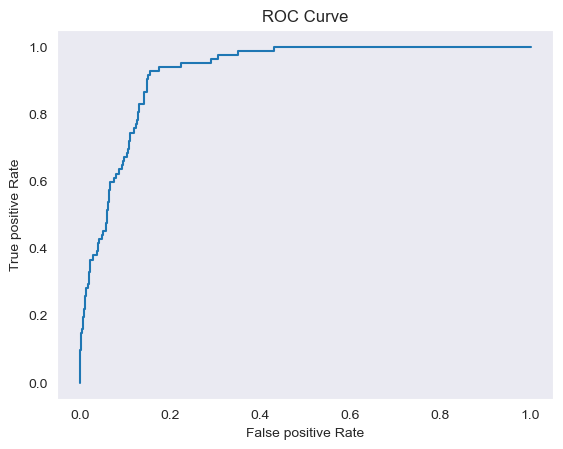

In [78]:
plt.plot(fpr, tpr)
plt.xlabel("False positive Rate")
plt.ylabel("True positive Rate")
plt.title("ROC Curve")
plt.show()

### Feature Importance

In [79]:
importance = GBC.feature_importances_
importance

array([0.01004718, 0.6168731 , 0.00375228, 0.00617491, 0.01202245,
       0.13836342, 0.00883567, 0.02411747, 0.0172135 , 0.1626    ])

In [80]:
x.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status'],
      dtype='object')

In [81]:
importance_df = pd.DataFrame({"Feature": x.columns, "Importance": importance}).sort_values(by="Importance", ascending=False)
importance_df

,Feature,Importance
1,age,0.616873
9,smoking_status,0.162600
5,work_type,0.138363
7,avg_glucose_level,0.024117
8,bmi,0.017213
4,ever_married,0.012022
0,gender,0.010047
6,Residence_type,0.008836
3,heart_disease,0.006175
2,hypertension,0.003752


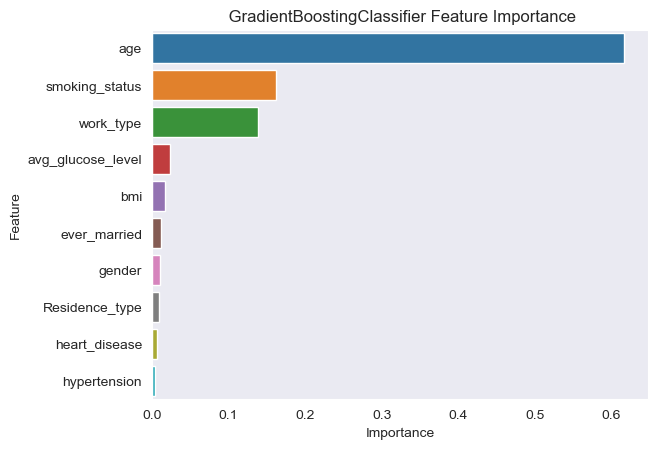

In [82]:
sns.barplot(data = importance_df, x = "Importance", y = "Feature", )
plt.title(" GradientBoostingClassifier Feature Importance")
plt.show()

##### Insight
Feature importance scores from the Gradient Boosting model indicate that age is the most influential predictor of stroke risk, contributing over 60% of the model’s decision-making. Lifestyle factors such as smoking status and work type also significantly impact the predictions. Clinical variables like heart disease and hypertension had comparatively low importance in this dataset, which may reflect either data characteristics or the model’s focus on demographic and behavioral risk factors.